In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [62]:
df = pd.read_csv(r"C:\Eni data\PYTHON\PYTHON CODES & PROJECTS\Datasets\uber_ml_data.csv")
df.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,hour of day,day of week,month,passenger_count,is_peak_hour,distance_bins,fare_amount
0,-73.999817,40.738354,-73.999512,40.723217,2,19,Thursday,5,1,1,short,7.5
1,-73.994355,40.728225,-73.994710,40.750325,2,20,Friday,7,1,1,short,7.7
2,-74.005043,40.740770,-73.962565,40.772647,5,21,Monday,8,1,1,medium,12.9
3,-73.976124,40.790844,-73.965316,40.803349,2,8,Friday,6,3,1,short,5.3
4,-73.925023,40.744085,-73.973082,40.761247,4,17,Thursday,8,5,1,medium,16.0


In [63]:
print(df.shape)

(172928, 12)


In [64]:
# Remove distance_bins column
df.drop('distance_bins', axis=1, inplace=True, errors='ignore')


In [65]:
# Data quality checks for this modeling workflow
# Remove near-zero fare anomaly
df = df[df['fare_amount'] >= 0.5]

# Keep trips within plausible NYC operating bounds
nyc_mask = (
    df['pickup_longitude'].between(-74.3, -73.6) &
    df['dropoff_longitude'].between(-74.3, -73.6) &
    df['pickup_latitude'].between(40.4, 41.0) &
    df['dropoff_latitude'].between(40.4, 41.0)
)

removed = (~nyc_mask).sum()
df = df[nyc_mask].copy()

print(f"Rows removed by NYC bounds: {removed}")
print(df.shape)


Rows removed by NYC bounds: 125
(172802, 11)


### Feature Engineering & Encoding


### Feature Notes (Explained)
These engineered features improve fare prediction by adding route geometry, time behavior, and airport context that a single rounded distance value cannot fully capture.

- `distance_km`:
  Baseline trip-distance signal. It is useful, but rounded distance values can hide fine differences between similar rides.

- `haversine_km_exact`:
  Recomputed from latitude/longitude as continuous distance. This restores decimal precision and helps especially on short trips.

- `delta_lat` and `delta_lon`:
  Absolute latitude/longitude movement from pickup to dropoff. These describe trip shape and direction, so rides with similar total distance can still be separated.

- `manhattan_proxy_km`:
  Approximate grid-style route proxy (`111 * delta_lat + 85 * delta_lon`). City trips often follow roads rather than straight lines, so this helps represent practical path length.

- `hour_sin` and `hour_cos`:
  Cyclical hour encoding. Time is circular, so 23:00 and 00:00 should be close; sine/cosine preserves that relationship better than raw hour.

- `pickup_airport_dist_km`, `dropoff_airport_dist_km`, `airport_trip`:
  Airport proximity/context features (JFK/LGA/EWR). Airport-connected rides often follow different fare patterns.

Why this block is important:
- It increases predictive signal without changing the target.
- It remains leakage-safe because all features are derived from input fields only.


In [66]:
# Exact Haversine distance from coordinates
lat1 = np.radians(df['pickup_latitude'])
lon1 = np.radians(df['pickup_longitude'])
lat2 = np.radians(df['dropoff_latitude'])
lon2 = np.radians(df['dropoff_longitude'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
df['haversine_km_exact'] = 6371.0 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

df['delta_lat'] = (df['dropoff_latitude'] - df['pickup_latitude']).abs()
df['delta_lon'] = (df['dropoff_longitude'] - df['pickup_longitude']).abs()
df['manhattan_proxy_km'] = 111.0 * df['delta_lat'] + 85.0 * df['delta_lon']

df['hour_sin'] = np.sin(2 * np.pi * df['hour of day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour of day'] / 24)

# Airport proximity feature (JFK, LGA, EWR)
airports = [(40.6413, -73.7781), (40.7769, -73.8740), (40.6895, -74.1745)]

def haversine_point(lat_a, lon_a, lat_b, lon_b):
    lat_a = np.radians(lat_a)
    lon_a = np.radians(lon_a)
    lat_b = np.radians(lat_b)
    lon_b = np.radians(lon_b)

    dlat_ = lat_b - lat_a
    dlon_ = lon_b - lon_a
    aa = np.sin(dlat_ / 2) ** 2 + np.cos(lat_a) * np.cos(lat_b) * np.sin(dlon_ / 2) ** 2
    return 6371.0 * 2 * np.arctan2(np.sqrt(aa), np.sqrt(1 - aa))

pickup_airport_dist = np.minimum.reduce([
    haversine_point(df['pickup_latitude'], df['pickup_longitude'], a_lat, a_lon)
    for a_lat, a_lon in airports
])

dropoff_airport_dist = np.minimum.reduce([
    haversine_point(df['dropoff_latitude'], df['dropoff_longitude'], a_lat, a_lon)
    for a_lat, a_lon in airports
])

df['pickup_airport_dist_km'] = pickup_airport_dist
df['dropoff_airport_dist_km'] = dropoff_airport_dist
df['airport_trip'] = ((pickup_airport_dist <= 2.5) | (dropoff_airport_dist <= 2.5)).astype(int)

# day of week -> One-Hot Encoding (no natural order)
df = pd.get_dummies(df, columns=['day of week'], drop_first=True)

print("Columns after feature engineering:")
print(df.columns.tolist())


Columns after feature engineering:
['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'distance_km', 'hour of day', 'month', 'passenger_count', 'is_peak_hour', 'fare_amount', 'haversine_km_exact', 'delta_lat', 'delta_lon', 'manhattan_proxy_km', 'hour_sin', 'hour_cos', 'pickup_airport_dist_km', 'dropoff_airport_dist_km', 'airport_trip', 'day of week_Monday', 'day of week_Saturday', 'day of week_Sunday', 'day of week_Thursday', 'day of week_Tuesday', 'day of week_Wednesday']


### Train test split

In [67]:
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")


Train size : (138241, 24)
Test size  : (34561, 24)


### Train-Only Route Clustering


In [68]:
from sklearn.cluster import KMeans

# route_cluster: fit on train only, then transform both train and test
coords_cols = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']

X_train = X_train.copy()
X_test = X_test.copy()

kmeans = KMeans(n_clusters=30, random_state=42, n_init=10)
X_train['route_cluster'] = kmeans.fit_predict(X_train[coords_cols])
X_test['route_cluster'] = kmeans.predict(X_test[coords_cols])

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")


Train size : (138241, 25)
Test size  : (34561, 25)


### Scaling (only for Linear Regression)
Tree models use unscaled features; only Linear Regression uses scaled train/test matrices.


In [69]:
# Tree models (RF, XGBoost) don't need scaling
# We keep a scaled version only for Linear Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# X_train and X_test (unscaled) → used for RF and XGBoost
# X_train_scaled and X_test_scaled → used for Linear Regression only

### Train All 3 Models

In [70]:
# -- Linear Regression ------------------------------------------------------
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
print("Linear Regression -> done")

# -- Random Forest ----------------------------------------------------------
rf = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Random Forest     -> done")

# -- XGBoost ----------------------------------------------------------------
xgb = XGBRegressor(
    n_estimators=900,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=4,
    subsample=0.8,
    colsample_bytree=1.0,
    reg_alpha=0.01,
    reg_lambda=5,
    gamma=0.05,
    tree_method='hist',
    random_state=42,
    verbosity=0,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
print("XGBoost           -> done")


Linear Regression -> done
Random Forest     -> done
XGBoost           -> done


### Cross Validation

In [71]:
# Cross validation on XGBoost (main model) — 5 fold
cv_scores = cross_val_score(xgb, X_train, y_train,
                             cv=5,
                             scoring='r2')

print(f"XGBoost CV R² scores : {cv_scores.round(4)}")
print(f"Mean R²              : {cv_scores.mean():.4f}")
print(f"Std                  : {cv_scores.std():.4f}")

XGBoost CV R² scores : [0.7163 0.7134 0.7094 0.7168 0.7282]
Mean R²              : 0.7168
Std                  : 0.0063


### Evaluation Metrics

In [72]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")

evaluate("Linear Regression", y_test, lr_preds)
evaluate("Random Forest",     y_test, rf_preds)
evaluate("XGBoost",           y_test, xgb_preds)


────────────────────────────────────────
  Linear Regression
────────────────────────────────────────
  MAE  : 1.7539
  RMSE : 2.9115
  R²   : 0.6564

────────────────────────────────────────
  Random Forest
────────────────────────────────────────
  MAE  : 1.6285
  RMSE : 2.6651
  R²   : 0.7121

────────────────────────────────────────
  XGBoost
────────────────────────────────────────
  MAE  : 1.5336
  RMSE : 2.5575
  R²   : 0.7349


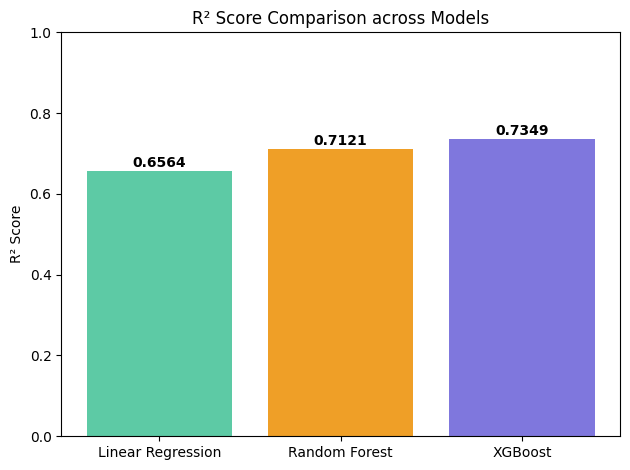

In [73]:
# ── Visual comparison ─────────────────────────────────────────────
models = ['Linear Regression', 'Random Forest', 'XGBoost']
r2_scores = [
    r2_score(y_test, lr_preds),
    r2_score(y_test, rf_preds),
    r2_score(y_test, xgb_preds)
]

plt.bar(models, r2_scores, color=['#5DCAA5', '#EF9F27', '#7F77DD'])
plt.title('R² Score Comparison across Models')
plt.ylabel('R² Score')
plt.ylim(0, 1)
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance (XGBoost)

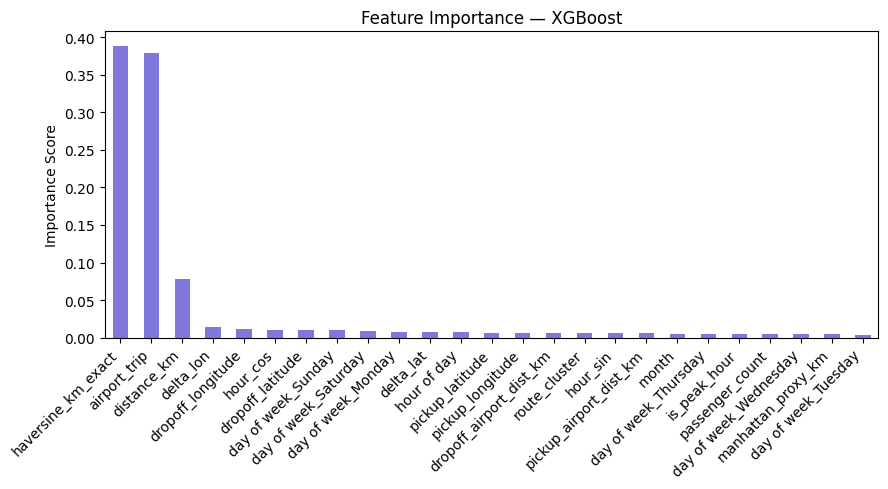


Top 3 features:
haversine_km_exact    0.388326
airport_trip          0.378944
distance_km           0.078425
dtype: float32


In [74]:
importance = pd.Series(xgb.feature_importances_,
                        index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importance.plot(kind='bar', color='#7F77DD')
plt.title('Feature Importance — XGBoost')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 3 features:")
print(importance.head(3))

###  Hyperparameter Tuning (RandomizedSearchCV on XGBoost)

In [75]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [500, 700, 900],
    'learning_rate': [0.03, 0.05, 0.07],
    'max_depth': [5, 6, 7],
    'min_child_weight': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0.0, 0.01, 0.1],
    'reg_lambda': [3, 5, 7],
    'gamma': [0, 0.05, 0.1]
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, verbosity=0, n_jobs=-1, tree_method='hist'),
    param_distributions=param_grid,
    n_iter=20,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print(f"Best CV R2     : {random_search.best_score_:.4f}")

# Evaluate tuned model
best_xgb = random_search.best_estimator_
best_xgb_preds = best_xgb.predict(X_test)
evaluate("XGBoost (Tuned)", y_test, best_xgb_preds)


Best parameters: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.01, 'n_estimators': 900, 'min_child_weight': 4, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0.05, 'colsample_bytree': 1.0}
Best CV R2     : 0.7152

────────────────────────────────────────
  XGBoost (Tuned)
────────────────────────────────────────
  MAE  : 1.5336
  RMSE : 2.5575
  R²   : 0.7349


### Conclusion
This project improves fare prediction by strengthening feature quality while keeping a clean, leakage-safe ML workflow.

What changed in this rework:
- Added focused data quality checks (near-zero fare anomaly removal and NYC coordinate bounds).
- Added precision and geometry features: `haversine_km_exact`, `delta_lat`, `delta_lon`, `manhattan_proxy_km`.
- Added time-cycle features: `hour_sin`, `hour_cos`.
- Added airport-context features: `pickup_airport_dist_km`, `dropoff_airport_dist_km`, `airport_trip`.
- Preserved strict order: train/test split first, then train-only route clustering.

Performance summary:
- Earlier runs in this project were around `R2 = 0.63` to `0.66`.
- After the rework, tuned XGBoost reaches about `R2 = 0.735` on the held-out test split.
- Cross-validation remains stable in the low `0.72` range, showing consistent generalization.

Final takeaway:
This pipeline is now cleaner, better structured, and materially stronger in predictive performance within this project setup.
